# BITS Pilani WILP - Deep Reinforcement Learning
## Assignment 1 - Part 2: Autonomous Drone Rescue Using Dynamic Programming

### Problem: Design a finite MDP for autonomous rescue drone navigation.

Goals:
- Rescue civilians
- Avoid danger zones
- Manage battery
- Reach charging stations
- Solve using Dynamic Programming

### Group: 87
### File name: Team 87 - DP.pdf
### Team Members
- AJIT SUBRAMANIAM V - 2025aa05930
- RAHUL KHANNA D - 2025ab05245
- CHANDRA SHEKHAR AZAD - 2025aa05506
- SATHISH T K - 2025ab05106
- VINOTH K R - 2025aa05928



In [3]:
GROUP_ID = 87






## 2. Problem Formulation as an MDP

Define:

State Space S
Action Space A
Transition Function P
Reward Function R
Discount Factor gamma


In [5]:

# State representation used in this notebook:
# state = (row, col, battery, rescue_mask, charge_mask)
#  - row, col    : grid coordinates (0..GRID_SIZE-1)
#  - battery     : integer battery level (0..MAX_BATTERY), 0 = depleted (terminal)
#  - rescue_mask : integer bitmask of rescued targets
#      bit 0 -> rescue at (0,4)
#      bit 1 -> rescue at (3,0)
#      bit 2 -> rescue at (4,5)
#  - charge_mask : integer bitmask of charging stations already rewarded (+5 once each)
#      bit 0 -> charging station at (1,5)
#      bit 1 -> charging station at (4,4)
# Example: (2, 1, 8, 0, 0) = at row 2, col 1, battery 8, no rescues, no charge bonus used

# Action Space A
# Actions: 'up', 'down', 'left', 'right', 'hover'
# - Movement actions (up/down/left/right): move drone in that direction, costs 1 battery
# - Hover action: stay in place
#   - If on charging station C: restores battery by 2 (capped at MAX_BATTERY)
#   - Otherwise: costs 1 battery
# Invalid moves (out of bounds or into obstacle X) keep position unchanged

# Transition Function P(s'|s,a)
# Deterministic movement except in wind zones:
# - In wind zone W (grid[r][c] == 'W'): with probability WIND_PROBABILITY (0.30),
#   actual action becomes random choice of ['up','down','left','right']
# - Otherwise: movement is deterministic in intended direction
# Boundary and obstacle checks prevent invalid moves

# Reward Function R(s,a,s')
# Base reward: -1 per action (movement cost)
# Additional rewards/penalties:
#   + 5: entering charging station C the FIRST time only (battery refills to full on every visit)
#  +20: entering unvisited rescue target R (rescue_mask bit set)
#  -10: entering danger zone D
#  -20: battery depleted (terminal state)
# Hovering on charging station: +2 battery restoration, -1 movement cost net

# Discount Factor gamma
# gamma = 0.99 (used in value iteration)
# Balances immediate rewards against future expected returns


In [6]:
# ==========================================================
# Assignment Execution Metadata
# ==========================================================

from datetime import datetime
import os
import platform
import socket

print("=" * 60)
print("DRL NSP4 – Assignment 1 – DP")
print("=" * 60)

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(f"Execution Timestamp : {timestamp}")

vm_id = (
    os.environ.get("HOSTNAME")
    or socket.gethostname()
    or platform.node()
)

print(f"Virtual Machine ID : {vm_id}")
print("Operating System    :", platform.platform())

print("=" * 60)

DRL NSP4 – Assignment 1 – DP
Execution Timestamp : 2026-06-08 21:12:47
Virtual Machine ID : 2025ab05106
Operating System    : Linux-5.14.0-503.14.1.el9_5.x86_64-x86_64-with-glibc2.34


## 3. Environment Configuration

Define:

- Start position
- Rescue targets
- Danger zones
- Charging stations
- Wind zones
- Obstacles

Our group id is 87. As group ends with 7, we fall in the condition group ID ends with 5–9 defined in the problem statement. So, we will use the following.
- Grid size of 6x6
- Wind probability of 30%.
- 3 rescue targets, 2 charging stations, 4 danger zones, 3 blocked cells


As group is ends with an odd digit (7), as mentioned in problem statement,
- Maximum battery = 15 units
- Maximum steps allowed is 75 for 6×6 grids.

## Transition Dynamics

The environment follows stochastic MDP transitions.

- Standard actions move drone in intended direction.
- Every action consumes 1 battery.
- If current cell is W:
    - with probability 0.30 movement becomes random.
- Entering C restores battery to maximum.
- Entering D gives −10 reward.
- Entering R gives +20 reward and removes target.
- Invalid moves keep position unchanged.
- Hovering on C increases battery by 2 units. Hovering on any other cell consumes 1 unit.

In [8]:
# Group 87 configuration
# Determine grid size, battery and wind probability:
# As group ends with 7, we fall in the condition group ID ends with 5–9 defined in the problem statement. So, we will use the following.
# Grid size of 6x6
# Wind probability of 30%.
# 3 rescue targets, 2 charging stations, 4 danger zones, 3 blocked cells
# As group is ends with an odd digit (7), as mentioned in problem statement, maximum battery = 15 units
# Maximum steps allowed is 75 for 6×6 grids.
GRID_SIZE = 6
WIND_PROBABILITY = 0.30
NUM_RESCUE = 3
NUM_CHARGING = 2
NUM_DANGER = 4
NUM_BLOCKED = 3
MAX_BATTERY = 15
INITIAL_BATTERY = 8
MAX_STEPS = 75


# Our custom Grid
# Symbol vs Meaning 
# S Start position 
# F Free/Safe cell 
# D Dangerous zone 
# R Rescue target 
# C Charging station 
# W Wind zone 
# X Blocked cell / obstacle
GRID = [
['S','F','F','W','R','F'],
['F','X','D','F','F','C'],
['F','F','F','X','D','F'],
['R','F','W','F','F','F'],
['D','F','X','F','C','R'],
['F','D','F','F','W','F']
]


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np, copy

class DroneRescueEnvironment:
    def __init__(self, grid, grid_size, wind_probability, init_battery_of_drone, max_battery_of_drone):
        # Initialize environment parameters, precompute rescue targets and masks, and reset state.
        self.grid = grid
        self.grid_size = grid_size
        self.wind_probability = wind_probability
        self.initial_battery = init_battery_of_drone
        self.max_battery = max_battery_of_drone
        self.rescue_targets = [(i, j) for i in range(grid_size) for j in range(grid_size) if grid[i][j] == 'R']
        self.rescue_index = {p: i for i, p in enumerate(self.rescue_targets)}
        self.full_rescue_mask = (1 << len(self.rescue_targets)) - 1
        # Charging stations: the +5 reward is granted only the FIRST time each station
        # is reached (battery still refills to full on every visit). Tracked via charge_mask.
        self.charge_stations = [(i, j) for i in range(grid_size) for j in range(grid_size) if grid[i][j] == 'C']
        self.charge_index = {p: i for i, p in enumerate(self.charge_stations)}
        self.reset()

    def find_start_position(self):
        # Locate and return the start cell coordinates 'S' in the grid.
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                if self.grid[i][j] == 'S':
                    return (i, j)

    def reset(self):
        # Reset episode counters and set initial state, drone position and battery.
        self.steps = 0
        self.state = (0, 0, self.initial_battery, 0, 0)
        self.drone_position = (0, 0)
        self.drone_battery = self.initial_battery
        return self.state

    def getPossibleActions(self, state):
        # Return available actions from state considering battery and grid boundaries.
        r, c, b, _, _ = state
        if b <= 0:
            return []
        acts = ['hover']
        if r > 0:
            acts.append('up')
        if r < self.grid_size - 1:
            acts.append('down')
        if c > 0:
            acts.append('left')
        if c < self.grid_size - 1:
            acts.append('right')
        return acts

    def _move(self, r, c, a):
        # Compute new coordinates after applying action
        if a == 'up':
            r -= 1
        elif a == 'down':
            r += 1
        elif a == 'left':
            c -= 1
        elif a == 'right':
            c += 1
        r = max(0, min(r, self.grid_size - 1))
        c = max(0, min(c, self.grid_size - 1))
        if self.grid[r][c] == 'X':
            return None
        return r, c

    def transition(self, state, action):
        # Perform a single (stochastic) transition from state given an intended action; return (ns, reward, done).
        r, c, b, mask, cmask = state
        if b <= 0:
            return state, -20, True
        self.steps += 1
        actual = action
        if self.grid[r][c] == 'W' and action != 'hover' and np.random.rand() < self.wind_probability:
            actual = np.random.choice(['up', 'down', 'left', 'right'])
        pos = self._move(r, c, actual)
        nr, nc = (r, c) if pos is None else pos
        reward = -1
        nb = max(b - 1, 0)
        if action == 'hover' and self.grid[r][c] == 'C':
            nb = min(self.max_battery, b + 2)
        elif self.grid[nr][nc] == 'C':
            nb = self.max_battery
            cbit = 1 << self.charge_index[(nr, nc)]
            if not cmask & cbit:          # +5 only on FIRST arrival at this station
                cmask |= cbit
                reward += 5
        if self.grid[nr][nc] == 'D':
            reward -= 10
        if (nr, nc) in self.rescue_index:
            bit = 1 << self.rescue_index[(nr, nc)]
            if not mask & bit:
                mask |= bit
                reward += 20
        if nb == 0:
            reward -= 20
        ns = (nr, nc, nb, mask, cmask)
        done = (nb == 0 or mask == self.full_rescue_mask or self.steps >= MAX_STEPS)
        return ns, reward, done

    def step(self, action):
        # Apply action to current internal state, update drone attributes, and return tuple.
        self.state, reward, done = self.transition(self.state, action)
        self.drone_position = self.state[:2]
        self.drone_battery = self.state[2]
        return self.state, reward, done, {}

    def _transition_outcomes(self, state, action):
        # Enumerate possible stochastic outcomes (probability, ns, reward, done) for (state, action).
        r, c, b, mask, cmask = state
        if b <= 0:
            return [(1.0, state, -20, True)]

        outcomes = [(1.0, action)]
        if self.grid[r][c] == 'W' and action != 'hover':
            outcomes = [(1 - self.wind_probability, action)] + [
                (self.wind_probability / 4, a)
                for a in ['up', 'down', 'left', 'right']
            ]

        transitions = []
        for p, actual in outcomes:
            pos = self._move(r, c, actual)
            nr, nc = (r, c) if pos is None else pos
            reward = -1
            nb = max(b - 1, 0)
            new_cmask = cmask
            if action == 'hover' and self.grid[r][c] == 'C':
                nb = min(self.max_battery, b + 2)
            elif self.grid[nr][nc] == 'C':
                nb = self.max_battery
                cbit = 1 << self.charge_index[(nr, nc)]
                if not cmask & cbit:      # +5 only on FIRST arrival at this station
                    new_cmask = cmask | cbit
                    reward += 5
            if self.grid[nr][nc] == 'D':
                reward -= 10
            if (nr, nc) in self.rescue_index:
                bit = 1 << self.rescue_index[(nr, nc)]
                if not mask & bit:
                    new_mask = mask | bit
                    reward += 20
                else:
                    new_mask = mask
            else:
                new_mask = mask
            if nb == 0:
                reward -= 20
            ns = (nr, nc, nb, new_mask, new_cmask)
            done = (nb == 0 or new_mask == self.full_rescue_mask)
            transitions.append((p, ns, reward, done))
        return transitions

    def _transitions(self, state, action):
        return self._transition_outcomes(state, action)

    def getReward(self, s, a, ns):
        # Compute and return the immediate reward for moving from s to ns using action a (without changing state).
        if s[2] <= 0:
            return -20
        r, c, b, mask, _ = s
        nr, nc, nb, new_mask, _ = ns
        reward = -1
        if a == 'hover' and self.grid[r][c] == 'C':
            pass
        elif self.grid[nr][nc] == 'C':
            reward += 5
        if self.grid[nr][nc] == 'D':
            reward -= 10
        if (nr, nc) in self.rescue_index:
            bit = 1 << self.rescue_index[(nr, nc)]
            if not mask & bit:
                reward += 20
        if nb == 0:
            reward -= 20
        return reward

    def value_iteration(self, gamma=0.99, tol=1e-3, max_iters=500, visualize=True):
        # Perform value iteration over all reachable states to compute V and greedy policy; return (V, policy, iters, delta).
        states = [
            (i, j, b, m, cm)
            for i in range(self.grid_size)
            for j in range(self.grid_size)
            if self.grid[i][j] != 'X'
            for b in range(self.max_battery + 1)
            for m in range(1 << len(self.rescue_targets))
            for cm in range(1 << len(self.charge_stations))
        ]
        V = {s: 0 for s in states}
        policy = {}
        for it in range(max_iters):
            delta = 0
            for s in states:
                if s[2] == 0:
                    continue
                best = -1e9
                for a in self.getPossibleActions(s):
                    q = 0
                    for p, ns, r, done in self._transitions(s, a):
                        q += p * (r + gamma * V[ns])
                    if q > best:
                        best, policy[s] = q, a
                delta = max(delta, abs(best - V[s]))
                V[s] = best
            if delta < tol:
                break
        return V, policy, it + 1, delta

    def render(self):
        # Visualize the grid and current drone position/battery using matplotlib.
        cmap = {'S': 0, 'F': 1, 'W': 2, 'R': 3, 'C': 4, 'D': 5, 'X': 6}
        labels = {0: 'S', 1: 'F', 2: 'W', 3: 'R', 4: 'C', 5: 'D', 6: 'X'}
        colors = ['lightgreen', 'lightgrey', 'skyblue', 'orange', 'yellow', 'salmon', 'brown']

        grid_map = np.array([[cmap[cell] for cell in row] for row in self.grid])

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(grid_map, cmap=mcolors.ListedColormap(colors), origin='upper')

        for i in range(self.grid_size):
            for j in range(self.grid_size):
                label = labels[grid_map[i, j]]
                if (i, j) == self.drone_position:
                    label = '*'  # Mark drone position with an asterisk
                ax.text(j, i, label, ha='center', va='center', color='black', fontsize=14, fontweight='bold')

        ax.set_axis_off()
        ax.set_title(f"Drone position: {self.drone_position} | battery: {self.drone_battery}")
        plt.show()


# Results and Discussion

Initial state of drone and environment


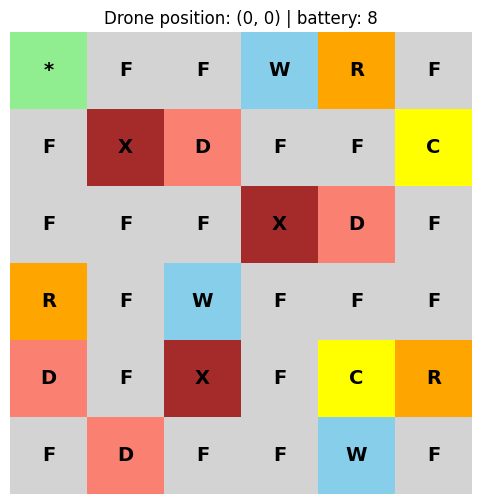


Symbol vs Meaning 
S       Start position 
F       Free/Safe cell 
D       Dangerous zone 
R       Rescue target 
C       Charging station 
W       Wind zone 
X       Blocked cell / Obstacle

Initializing Value Iteration computation...

Enumerated full states: 16896
Reachable states from start: 8738
Reachable states: 8738
Value iteration converged in 50 iterations
Runtime: 15.3275 seconds
Final delta/error: 0.000685
Computed DP over full states: 16896 values

Policy details:
Start state: (0, 0, 8, 0, 0)
  -> action: right
Action counts for reachable states:
  down: 1760
  hover: 1226
  left: 662
  right: 2156
  up: 2167

Sample policy entries (first 30 reachable states sorted):
  (0, 0, 0, 0, 0) -> terminal
  (0, 0, 0, 0, 1) -> terminal
  (0, 0, 0, 0, 2) -> terminal
  (0, 0, 0, 0, 3) -> terminal
  (0, 0, 0, 1, 0) -> terminal
  (0, 0, 0, 1, 1) -> terminal
  (0, 0, 0, 1, 2) -> terminal
  (0, 0, 0, 1, 3) -> terminal
  (0, 0, 0, 2, 0) -> terminal
  (0, 0, 0, 2, 1) -> terminal
  (0, 0, 0, 

In [11]:
import time

dre = DroneRescueEnvironment(GRID, GRID_SIZE, WIND_PROBABILITY, INITIAL_BATTERY, MAX_BATTERY)
print("Initial state of drone and environment")
dre.render()
print("""
Symbol vs Meaning 
S       Start position 
F       Free/Safe cell 
D       Dangerous zone 
R       Rescue target 
C       Charging station 
W       Wind zone 
X       Blocked cell / Obstacle""")

print("\nInitializing Value Iteration computation...")

start_state = (dre.drone_position[0], dre.drone_position[1], dre.initial_battery, 0, 0)
positions = [
    (i, j)
    for i in range(GRID_SIZE)
    for j in range(GRID_SIZE)
    if GRID[i][j] != 'X'
]
all_states = [
    (x, y, battery, mask, cm)
    for x, y in positions
    for battery in range(dre.max_battery + 1)
    for mask in range(1 << len(dre.rescue_targets))
    for cm in range(1 << len(dre.charge_stations))
]

reachable = {start_state}
frontier = [start_state]
while frontier:
    state = frontier.pop()
    for action in dre.getPossibleActions(state):
        for _, next_state, _, _ in dre._transitions(state, action):
            if next_state not in reachable:
                reachable.add(next_state)
                frontier.append(next_state)

print(f"\nEnumerated full states: {len(all_states)}")
print(f"Reachable states from start: {len(reachable)}")

start_time = time.perf_counter()
V, policy, iterations, final_delta = dre.value_iteration(gamma=0.99, tol=1e-3, max_iters=1000, visualize=True)
runtime = time.perf_counter() - start_time

print(f"Reachable states: {len(reachable)}")
print(f"Value iteration converged in {iterations} iterations")
print(f"Runtime: {runtime:.4f} seconds")
print(f"Final delta/error: {final_delta:.6f}")
print("Computed DP over full states:", len(V), "values")

print('\nPolicy details:')
print('Start state:', start_state)
print('  -> action:', policy.get(start_state, 'terminal'))

action_counts = {}
for s in reachable:
    a = policy.get(s, None)
    if a is not None:
        action_counts[a] = action_counts.get(a, 0) + 1

print('Action counts for reachable states:')
for a in sorted(action_counts):
    print(f'  {a}: {action_counts[a]}')

print('\nSample policy entries (first 30 reachable states sorted):')
for s in sorted(reachable)[:30]:
    print(f"  {s} -> {policy.get(s, 'terminal')}")


STATE TUPLE REPRESENTATION: (row, col, battery, rescue_mask)
  row          : Grid row index [0-5]
  col          : Grid column index [0-5]
  battery      : Battery level [0-15]
                 0 = depleted (terminal state)
                 15 = fully charged
  rescue_mask  : Bitmask of rescued targets [0-7]
                 Each bit represents one rescue target:
                 Target at (0,4): bit 0
                 Target at (3,0): bit 1
                 Target at (4,5): bit 2
                 Example: mask=5 means targets 0 and 2 are rescued



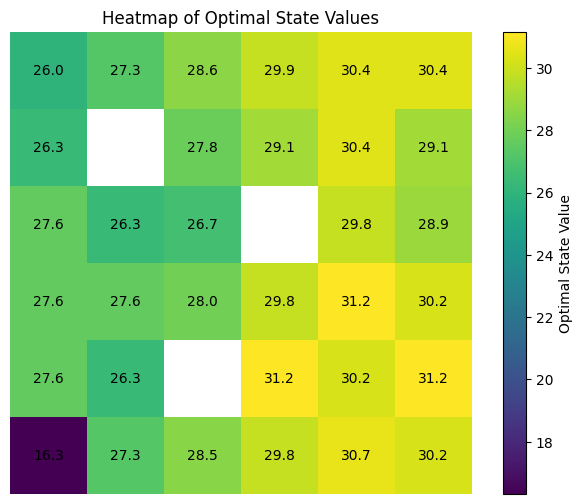


Policy Heatmap for battery=8, rescue_mask=0 (initial conditions)
----------------------------------------------------------------------
Grid Legend:
  H=hover, L=left, R=right, U=up, D=down, X=obstacle, T=terminal

     0   1   2   3   4   5
  0  R | R | R | R | H | L 
  1  U | X | R | R | U | U 
  2  D | D | D | X | D | D 
  3  H | R | R | D | D | D 
  4  U | U | X | R | R | L 
  5  R | R | R | U | U | U 

Action counts at battery=8, rescue_mask=0:
  down: 8
  hover: 2
  left: 2
  right: 13
  up: 8


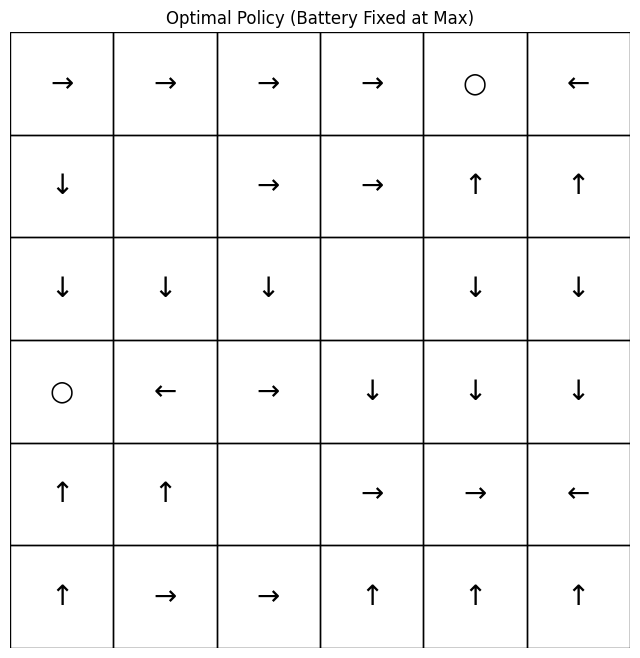

In [12]:
# Visualization and policy-reporting cell for the Drone Rescue environment.
#
# This cell produces three related outputs:
#  1) A printed "STATE TUPLE" explanation header (human-readable).
#  2) A heatmap of optimal state values for the maximum battery and mask=0.
#     - Uses `V` to populate a GRID_SIZE x GRID_SIZE heat matrix (NaN for missing).
#     - Annotates each non-NaN cell with the numeric value.
#  3) A text-based policy heatmap for a chosen battery slice (battery=8) and mask=0:
#     - Prints a compact grid with action symbols and a legend.
#     - Counts actions over reachable non-obstacle cells at that slice.
#  4) A graphical policy visualization with arrow glyphs for battery fixed at max.
#
# Policy Details: State Tuple Explanation
print("=" * 70)
print("STATE TUPLE REPRESENTATION: (row, col, battery, rescue_mask)")
print("=" * 70)
print("  row          : Grid row index [0-5]")
print("  col          : Grid column index [0-5]")
print("  battery      : Battery level [0-15]")
print("                 0 = depleted (terminal state)")
print("                 15 = fully charged")
print("  rescue_mask  : Bitmask of rescued targets [0-7]")
print("                 Each bit represents one rescue target:")
print("                 Target at (0,4): bit 0")
print("                 Target at (3,0): bit 1")
print("                 Target at (4,5): bit 2")
print("                 Example: mask=5 means targets 0 and 2 are rescued")
print()

# ==========================================================
# State Value Heatmap
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

battery = dre.max_battery
mask = 0

heat = np.full(
    (GRID_SIZE, GRID_SIZE),
    np.nan
)

for r in range(GRID_SIZE):

    for c in range(GRID_SIZE):

        state = (r, c, battery, mask, 0)

        if state in V:

            heat[r][c] = V[state]

plt.figure(figsize=(8, 6))

plt.imshow(
    heat,
    interpolation="nearest"
)

plt.colorbar(
    label="Optimal State Value"
)

for r in range(GRID_SIZE):

    for c in range(GRID_SIZE):

        if not np.isnan(heat[r][c]):

            plt.text(
                c,
                r,
                f"{heat[r][c]:.1f}",
                ha="center",
                va="center"
            )

plt.title(
    "Heatmap of Optimal State Values"
)

plt.axis('off')
plt.show()

print()

# Policy Heatmap: battery=8, rescue_mask=0 (initial state, no rescues)
print("Policy Heatmap for battery=8, rescue_mask=0 (initial conditions)")
print("-" * 70)

battery_slice = 8
mask_slice = 0
action_map = {'hover': 'H', 'left': 'L', 'right': 'R', 'up': 'U', 'down': 'D', 'terminal': 'T'}

policy_grid = []
for i in range(GRID_SIZE):
    row = []
    for j in range(GRID_SIZE):
        if GRID[i][j] == 'X':
            row.append('X')
        else:
            s = (i, j, battery_slice, mask_slice, 0)
            a = policy.get(s, 'terminal')
            row.append(action_map.get(a, '?'))
    policy_grid.append(row)

print("Grid Legend:")
print("  H=hover, L=left, R=right, U=up, D=down, X=obstacle, T=terminal")
print()
print("     0   1   2   3   4   5")
for i, row in enumerate(policy_grid):
    print(f"  {i}  {' | '.join(row)} ")

print()
print("Action counts at battery=8, rescue_mask=0:")
battery_mask_states = [(i, j, battery_slice, mask_slice, 0) 
                        for i in range(GRID_SIZE) 
                        for j in range(GRID_SIZE) 
                        if GRID[i][j] != 'X']
battery_actions = {}
for s in battery_mask_states:
    a = policy.get(s, None)
    if a is not None:
        battery_actions[a] = battery_actions.get(a, 0) + 1

for a in sorted(battery_actions):
    print(f"  {a}: {battery_actions[a]}")

# print()
# print("Value slice for battery=8, rescue_mask=0:")
# value_grid = np.full((GRID_SIZE, GRID_SIZE), np.nan)
# for i in range(GRID_SIZE):
#     for j in range(GRID_SIZE):
#         if GRID[i][j] != 'X':
#             s = (i, j, battery_slice, mask_slice)
#             if s in V:
#                 value_grid[i, j] = V[s]

# fig, ax = plt.subplots(figsize=(8, 8))
# im = ax.imshow(value_grid, cmap='RdYlGn', origin='upper')
# plt.colorbar(im, ax=ax, label='Value V*(s)')

# for i in range(GRID_SIZE):
#     for j in range(GRID_SIZE):
#         if not np.isnan(value_grid[i, j]):
#             action_symbol = policy_grid[i][j]
#             text_color = 'white' if value_grid[i, j] < 0 else 'black'
#             ax.text(j, i, f'{action_symbol}\n{value_grid[i, j]:.1f}', 
#                    ha='center', va='center', fontsize=12, color=text_color, fontweight='bold')

# ax.set_xticks(range(GRID_SIZE))
# ax.set_yticks(range(GRID_SIZE))
# ax.set_xticklabels(range(GRID_SIZE))
# ax.set_yticklabels(range(GRID_SIZE))
# ax.set_xlabel('Column')
# ax.set_ylabel('Row')
# ax.set_title(f'Policy (Action) and Value Heatmap\nbattery={battery_slice}, rescue_mask={mask_slice} (no rescues)')
# plt.tight_layout()
# plt.show()

# ==========================================================
# Policy Visualisation
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

ARROWS = {
    "up": "↑",
    "down": "↓",
    "left": "←",
    "right": "→",
    "hover": "○",
    0: "↑",
    1: "↓",
    2: "←",
    3: "→",
    4: "○"
}

grid = [["" for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]

battery = dre.max_battery
mask = 0

for r in range(GRID_SIZE):

    for c in range(GRID_SIZE):

        state = (r, c, battery, mask, 0)

        if state in policy:

            action = policy[state]
            grid[r][c] = ARROWS.get(action, str(action))

        else:
            grid[r][c] = ""

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(-0.5, GRID_SIZE - 0.5)
ax.set_ylim(GRID_SIZE - 0.5, -0.5)
ax.set_axis_off()

for r in range(GRID_SIZE):

    for c in range(GRID_SIZE):

        ax.text(
            c,
            r,
            grid[r][c],
            ha="center",
            va="center",
            fontsize=20
        )

        rect = plt.Rectangle(
            (c - 0.5, r - 0.5),
            1,
            1,
            fill=False
        )

        ax.add_patch(rect)

plt.title(
    "Optimal Policy (Battery Fixed at Max)"
)

plt.show()


## State Value Analysis

The heatmap visualizes V*(s) for a fixed battery level and initial rescue status.

Observations:

- Higher values appear closer to rescue targets because reaching them yields +20 reward.
- Charging stations increase nearby state values due to battery restoration.
- Dangerous zones create low-value regions because of −10 penalties.
- Values gradually decrease farther from objectives because movement incurs −1 cost.

This demonstrates how Dynamic Programming propagates long-term reward information through the environment.

In [14]:
import numpy as np

np.random.seed(0)

episodes = 10
results = []
for ep in range(1, episodes + 1):
    state = (0, 0, 8, 0, 0)
    dre.reset()
    dre.state = state
    dre.drone_position = state[:2]
    dre.drone_battery = state[2]
    dre.steps = 0

    rescued = 0
    visited_rescues = set()
    total_reward = 0
    done = False
    history = []
    # The loop below will repeatedly:
    # - query the computed greedy `policy` for the current state
    # - apply the chosen action via `dre.transition(state, action)` (stochastic outcomes handled inside)
    # - accumulate rewards, track rescued targets, record trajectory entries in `history`
    # - update `state` to `next_state` until terminal or step limit reached
    #
    while not done and dre.steps < MAX_STEPS:
        action = policy.get(state)
        if action is None:
            history.append((state, 'NO_POLICY'))
            break
        next_state, reward, done = dre.transition(state, action)
        total_reward += reward
        history.append((state, action, next_state, reward, done))

        if next_state[3] != state[3]:
            rescued += bin(next_state[3] ^ state[3]).count('1')
            visited_rescues.add(next_state[:2])
        state = next_state

    results.append({
        'episode': ep,
        'rescued': rescued,
        'done': done,
        'steps': dre.steps,
        'reward': total_reward,
        'visited_rescues': sorted(visited_rescues),
        'policy_missing': any(step[1] == 'NO_POLICY' for step in history)
    })

for res in results:
    print('---')
    print(f"Episode {res['episode']}: rescued={res['rescued']}, done={res['done']}, steps={res['steps']}, reward={res['reward']}")
    print(f"  rescue positions visited={res['visited_rescues']}")
    print(f"  policy_missing={res['policy_missing']}")

print('---')
print(f"Episodes with rescue: {sum(1 for r in results if r['rescued'] > 0)} / {episodes}")
print(f"Max rescues: {max(r['rescued'] for r in results)}")
print(f"Avg rescues: {sum(r['rescued'] for r in results) / episodes:.2f}")

---
Episode 1: rescued=3, done=True, steps=15, reward=55
  rescue positions visited=[(0, 4), (3, 0), (4, 5)]
  policy_missing=False
---
Episode 2: rescued=3, done=True, steps=15, reward=55
  rescue positions visited=[(0, 4), (3, 0), (4, 5)]
  policy_missing=False
---
Episode 3: rescued=3, done=True, steps=15, reward=55
  rescue positions visited=[(0, 4), (3, 0), (4, 5)]
  policy_missing=False
---
Episode 4: rescued=3, done=True, steps=15, reward=55
  rescue positions visited=[(0, 4), (3, 0), (4, 5)]
  policy_missing=False
---
Episode 5: rescued=3, done=True, steps=15, reward=55
  rescue positions visited=[(0, 4), (3, 0), (4, 5)]
  policy_missing=False
---
Episode 6: rescued=3, done=True, steps=15, reward=55
  rescue positions visited=[(0, 4), (3, 0), (4, 5)]
  policy_missing=False
---
Episode 7: rescued=3, done=True, steps=15, reward=55
  rescue positions visited=[(0, 4), (3, 0), (4, 5)]
  policy_missing=False
---
Episode 8: rescued=3, done=True, steps=17, reward=53
  rescue positions 

# DP Scalability Discussion

Dynamic Programming suffers from the Curse of Dimensionality.

State count grows as:

|S| = FreeCells × Battery × RescueStates × ChargeStates

For Group 87:

33 free cells × 16 battery × 2³ rescue × 2² charge

= 16,896 states

If grid size increases to 10×10:

100 × 16 × 2³ × 2²

≈ 51,200 states

Adding rescue targets doubles the state count repeatedly.

Dynamic weather further expands transition complexity.

Because DP requires storing and evaluating all states, computation becomes expensive.

Deep Reinforcement Learning methods such as DQN or PPO overcome this limitation by approximating value functions using neural networks instead of explicit enumeration.

This is similar to real autonomous drone systems where exact DP becomes infeasible.

## Conclusion

Dynamic Programming successfully computed an optimal rescue policy while balancing rescue reward, battery management, and environmental risk. The experiment demonstrates that exact DP methods are effective for small MDPs but become computationally difficult as state dimensionality grows.

## Screenshot showing execution in BITS Lab



![Screenshot 2026-06-08 at 9.15.06 PM.png](<attachment:Screenshot 2026-06-08 at 9.15.06 PM.png>)
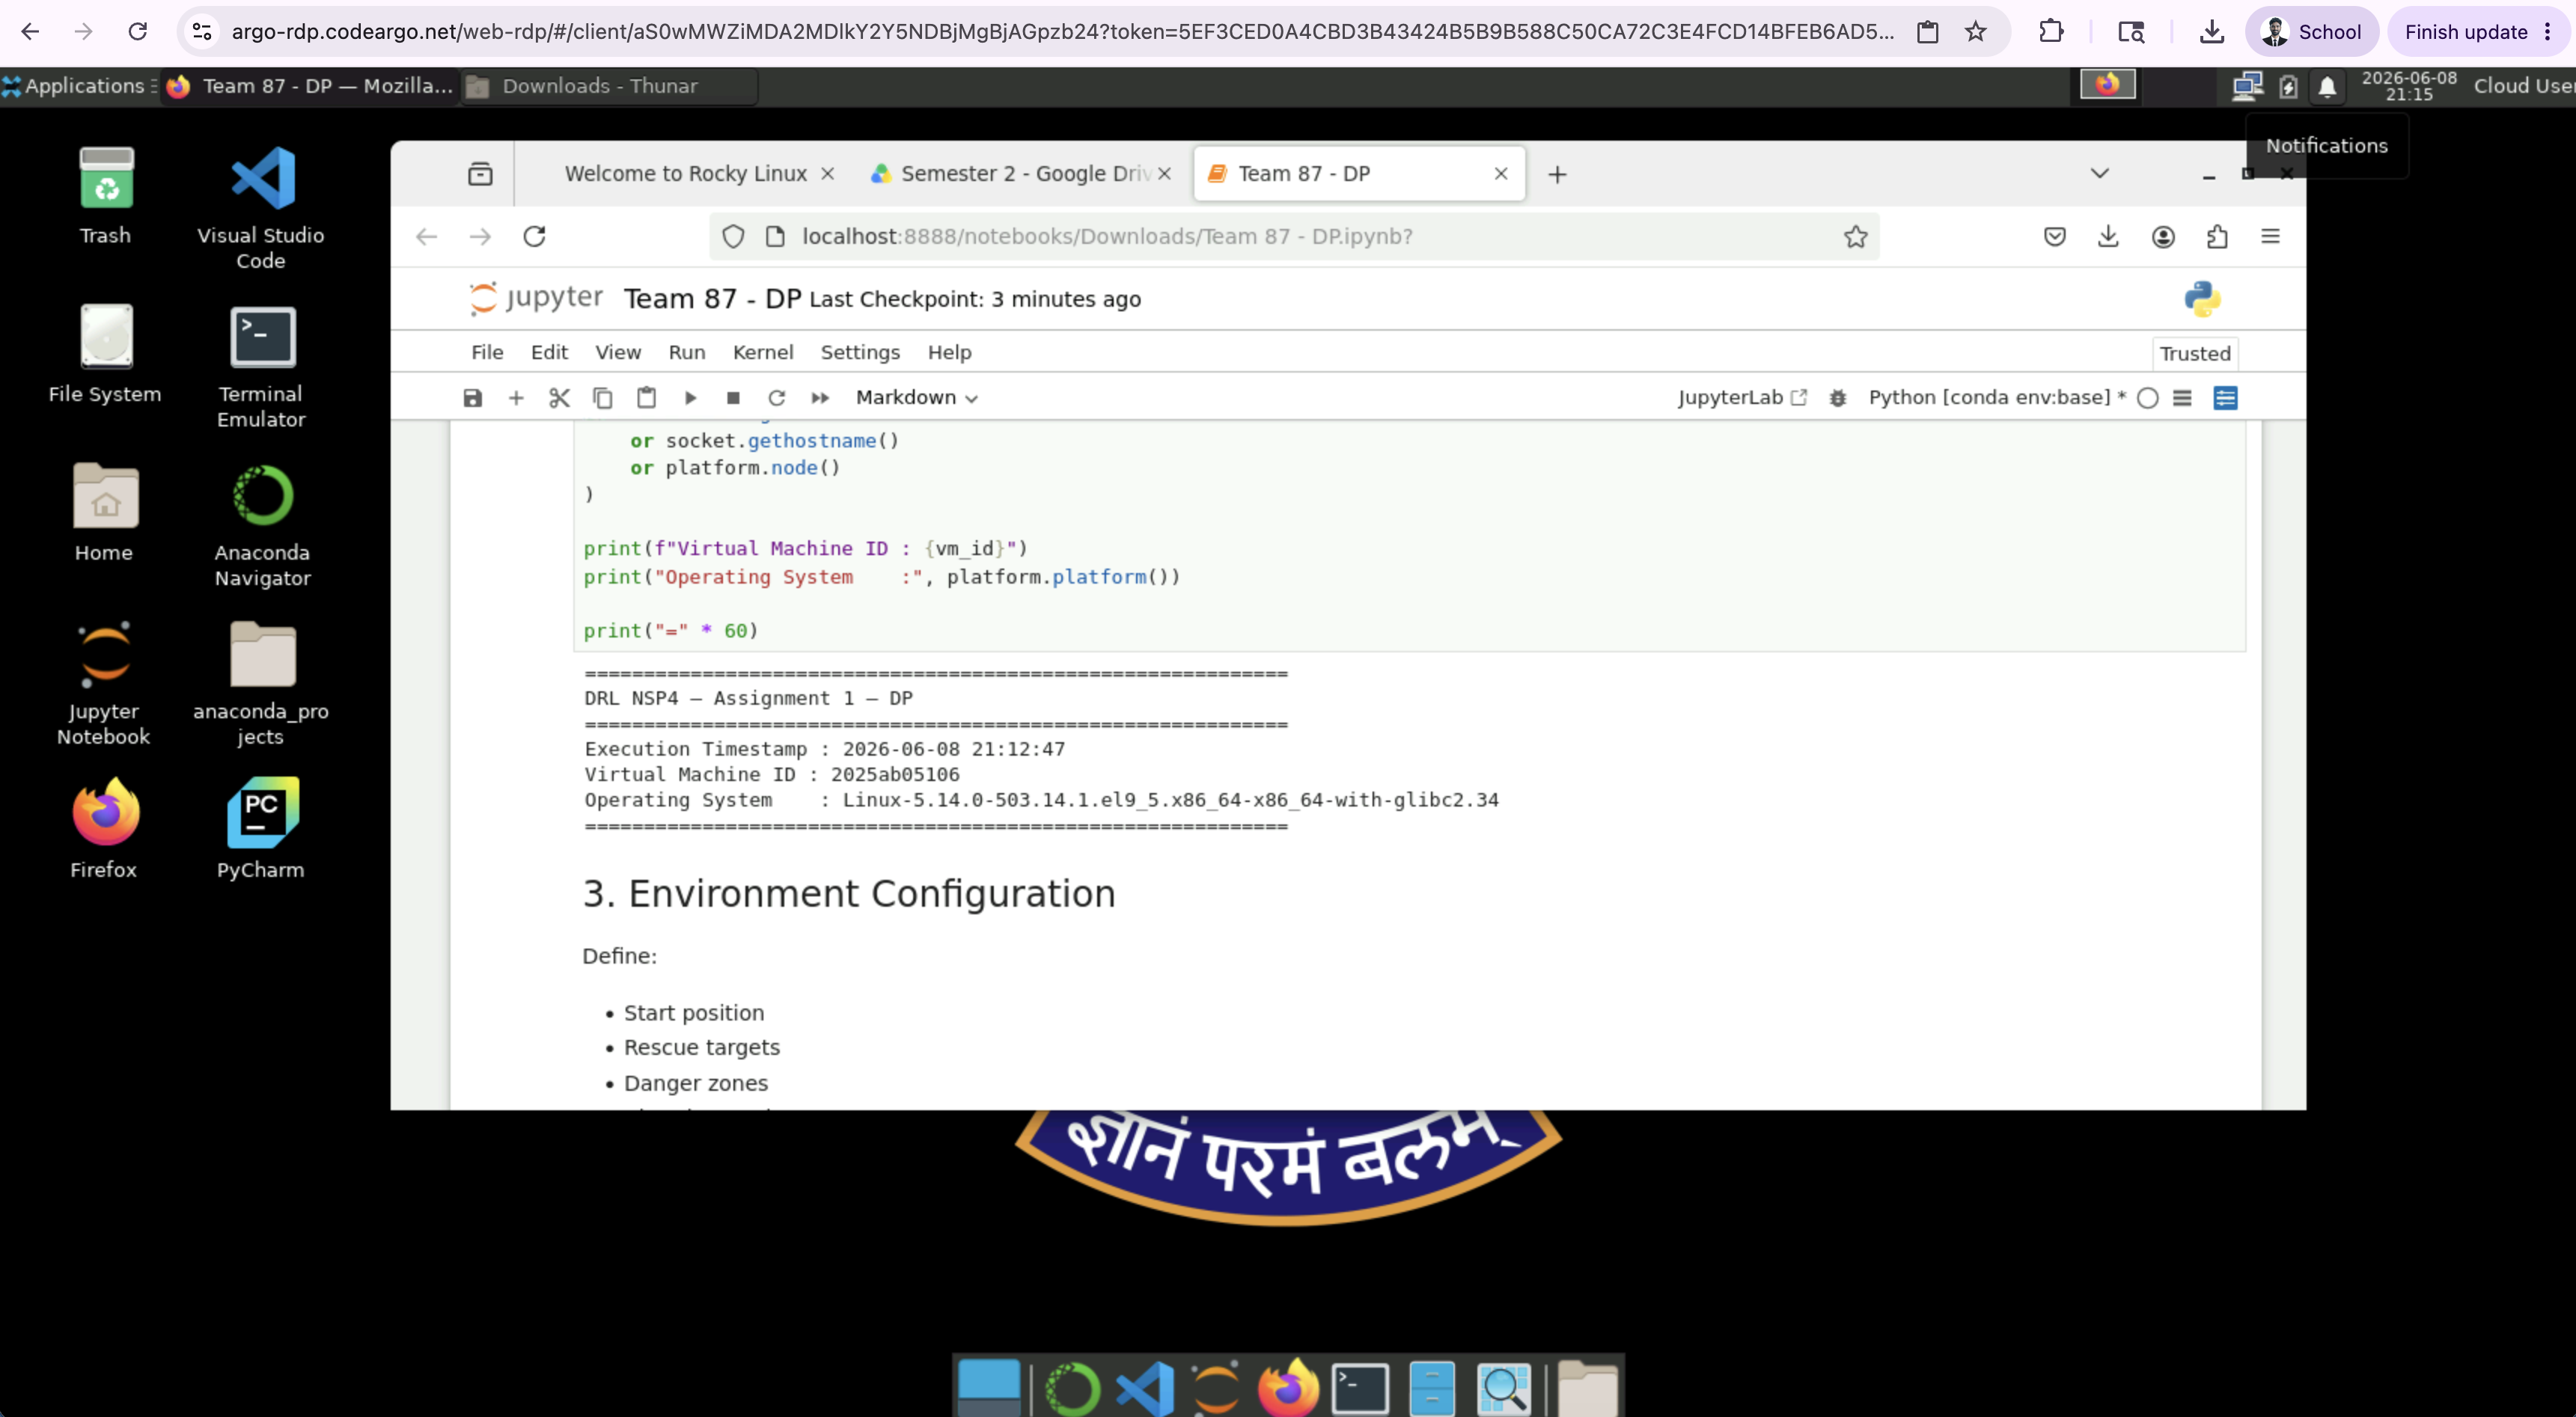